### Assignment 13

Title: MNIST Handwritten Character Detection using PyTorch, Keras and Tensorflow 

Problem Statement: Implement MNIST Handwritten Character Detection using PyTorch, Keras and Tensorflow

In [ ]:
# !pip install numpy matplotlib tensorflow keras torch torchvision

# (Latest version upgrade)
# !pip install -U numpy matplotlib tensorflow keras torch torchvision

#If tensorflow installation takes time
# !pip install tensorflow-cpu

## TensorFlow Implementation

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

In [2]:
# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
x_train

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [6]:
# Reshape for CNN
x_train = x_train.reshape(-1,28,28,1)  #1st param is batchsize, and to avoid writing it explicitly we mention -1
x_test = x_test.reshape(-1,28,28,1)

In [ ]:
# Model
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),

    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
    
])

In [64]:
# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9556 - loss: 0.1513 - val_accuracy: 0.9820 - val_loss: 0.0626
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9843 - loss: 0.0502 - val_accuracy: 0.9865 - val_loss: 0.0467
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9890 - loss: 0.0358 - val_accuracy: 0.9897 - val_loss: 0.0349
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9916 - loss: 0.0262 - val_accuracy: 0.9890 - val_loss: 0.0396
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9934 - loss: 0.0204 - val_accuracy: 0.9893 - val_loss: 0.0360


In [66]:
# Test
loss, acc = model.evaluate(x_test, y_test)
print("Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9893 - loss: 0.0347
Accuracy: 0.989300012588501


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


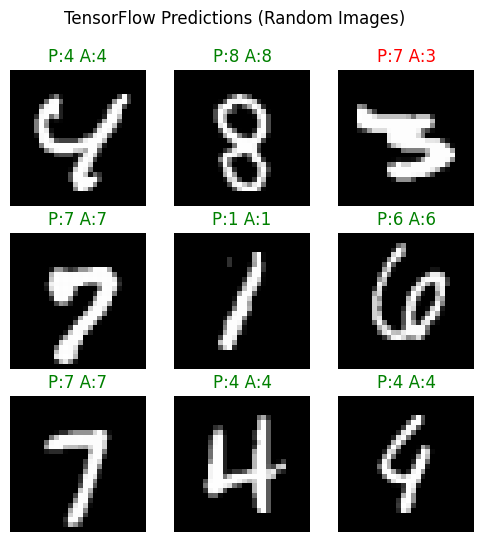

In [67]:
import random

predictions = model.predict(x_test)

plt.figure(figsize=(6,6))

for i in range(9):
    idx = random.randint(0, len(x_test)-1)
    
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
    
    pred = np.argmax(predictions[idx])
    actual = y_test[idx]
    
    color = "green" if pred == actual else "red"
    plt.title(f"P:{pred} A:{actual}", color=color)
    
    plt.axis('off')

plt.suptitle("TensorFlow Predictions (Random Images)")
plt.show()

## Keras Only Implementation

In [68]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.datasets import mnist

In [69]:
# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [70]:
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0


In [71]:

# Reshape
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)


In [72]:

# Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])



In [73]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])



In [74]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9588 - loss: 0.1366
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9861 - loss: 0.0450
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9904 - loss: 0.0315
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9924 - loss: 0.0241
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9944 - loss: 0.0172


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


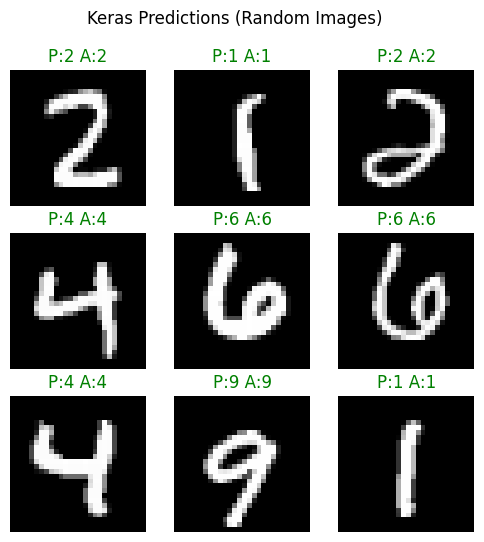

In [75]:
import random

random.seed(42)  # different selection

predictions = model.predict(x_test)

plt.figure(figsize=(6,6))

for i in range(9):
    idx = random.randint(0, len(x_test)-1)
    
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
    
    pred = np.argmax(predictions[idx])
    actual = y_test[idx]
    
    color = "green" if pred == actual else "red"
    plt.title(f"P:{pred} A:{actual}", color=color)
    
    plt.axis('off')

plt.suptitle("Keras Predictions (Random Images)")
plt.show()

## PyTorch Implementation

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

In [2]:
# Load dataset
transform = transforms.ToTensor()

In [3]:
train_data = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_data = torchvision.datasets.MNIST(root='./data', train=False, transform=transform)

100%|██████████| 9.91M/9.91M [00:02<00:00, 3.97MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


In [4]:
train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64)

In [ ]:
# CNN Model
class CNN(nn.Module):

    def __init__(self):

        super(CNN, self).__init__()

        self.conv = nn.Conv2d(1, 32, 3)
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(5408, 10)
    
    def forward(self, x):

        x = self.pool(torch.relu(self.conv(x)))
        x = x.view(-1, 5408)
        x = self.fc(x)
        
        return x


In [6]:
model = CNN()

In [7]:
# Loss + Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [8]:
# Training (1 epoch only for simplicity)
for epoch in range(1):
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

In [9]:
print("Training done")

Training done


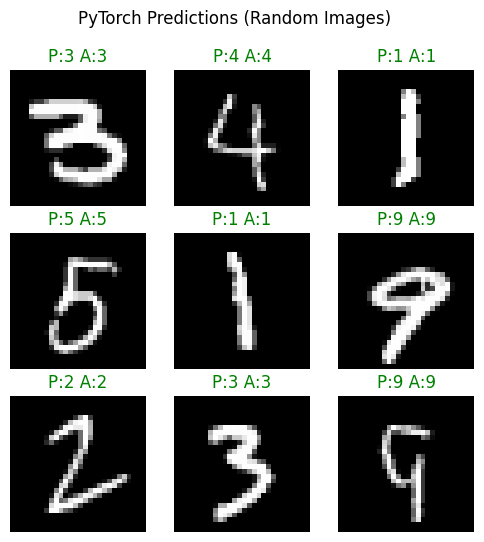

In [13]:
import random
# Get shuffled batch
test_loader_iter = iter(test_loader)
images, labels = next(test_loader_iter)

outputs = model(images)
_, preds = torch.max(outputs, 1)

plt.figure(figsize=(6,6))

for i in range(9):
    idx = random.randint(0, len(images)-1)
    
    plt.subplot(3,3,i+1)
    plt.imshow(images[idx].squeeze(), cmap='gray')
    
    pred = preds[idx].item()
    actual = labels[idx].item()
    
    color = "green" if pred == actual else "red"
    plt.title(f"P:{pred} A:{actual}", color=color)
    
    plt.axis('off')

plt.suptitle("PyTorch Predictions (Random Images)")
plt.show()